<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%A0%D0%9A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

# **Импорт данных**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/Admission_Predict.csv"
data = pd.read_csv("/content/drive/MyDrive/Admission_Predict.csv")

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,Yes,0.92
1,2,324,107,4,4,4.5,8.87,Yes,0.76
2,3,316,104,3,3,3.5,8.00,Yes,0.72
3,4,322,110,3,3.5,2.5,8.67,NaN,0.80
4,5,314,103,2,2,3,8.21,NaN,0.65


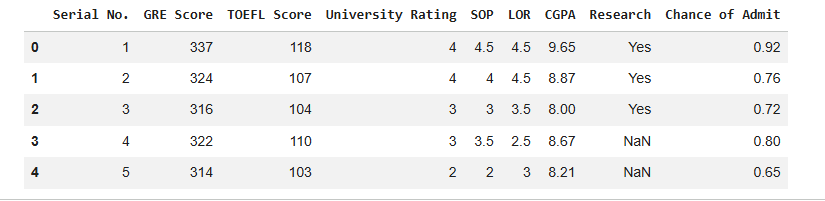

**Проверка пустых значений**

In [ ]:
data.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,23
Research,25
Chance of Admit,0


Я сама немного "испортила" датасет, чтобы иметь возможность заполнить пропуски как категориальные, так и количественные. Количество пустых значений по CGPA составило почти 6%, а по RESEARCH 6,25%
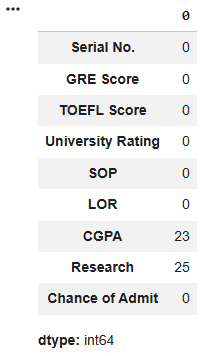

In [ ]:
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка CGPA. Тип данных float64. Количество пустых значений 23, 5.75%.


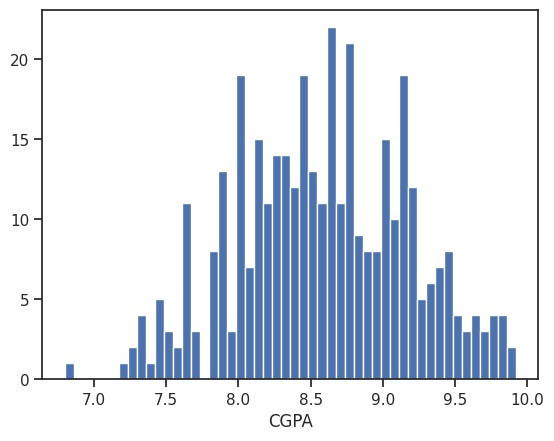

In [ ]:
data_num = data[num_cols]
data_num
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

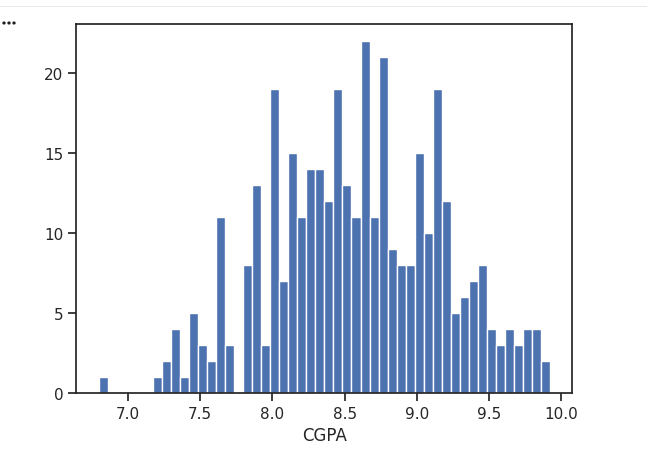

In [ ]:
data_num_MasVnrArea = data_num[['CGPA']]
data_num_MasVnrArea.head()

,CGPA
0,9.65
1,8.87
2,8.00
3,8.67
4,8.21


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [ ]:
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_MasVnrArea)
mask_missing_values_only

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

**ЗАПОЛНЕНИЕ ПРОБЕЛОВ ВЫБРАННОЙ СТРАТЕГИЕЙ**

In [ ]:
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_MasVnrArea)
    return data_num_imp[mask_missing_values_only]

In [ ]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57,
        8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57, 8.57,
        8.57]))

In [ ]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([8.58087533, 8.58087533, 8.58087533, 8.58087533, 8.58087533,
        8.58087533, 8.58087533, 8.58087533, 8.58087533, 8.58087533,
        8.58087533, 8.58087533, 8.58087533, 8.58087533, 8.58087533,
        8.58087533, 8.58087533, 8.58087533, 8.58087533, 8.58087533,
        8.58087533, 8.58087533, 8.58087533]))

В данной задаче я бы все же выбрала стратегию среднего значения, так как она дает более высокий результат среднего балла. В данной ситуации неопределенности я считаю, что более высокие результаты учеников дадут им большую возможность для поступления. А если считать нехватку данных ошибкой системы, то заполнение недостающих ячеек более высоким баллом, я считаю человечным.

**Работа с категориальными данными**

In [ ]:
cat_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Research. Тип данных object. Количество пустых значений 25, 6.25%.


In [ ]:
cat_temp_data = data[['Research']]
cat_temp_data.head()

,Research
0,Yes
1,Yes
2,Yes
3,NaN
4,NaN


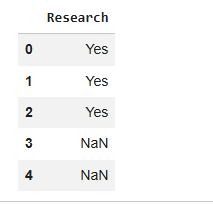

In [ ]:
cat_temp_data['Research'].unique()

array(['Yes', nan, 'No'], dtype=object)

In [ ]:
cat_temp_data[cat_temp_data['Research'].isnull()].shape

(25, 1)

In [ ]:
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='N/S')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['Yes'],
       ['Yes'],
       ['Yes'],
       ['N/S'],
       ['N/S'],
       ['N/S'],
       ['N/S'],
       ['No'],
       ['No'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['No'],
       ['Yes'],
       ['No'],
       ['No'],
       ['Yes'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['Yes'],
       ['No'],
       ['No'],
       ['Yes'],
       ['N/S'],
       ['N/S'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['No'],
       ['No'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['No'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['Yes'],
       ['N/S'],
       ['N/S'],
       ['N/S'],
       ['No'],
       ['Yes'],
       ['No'],
       ['No'],
       ['No'],
       ['Yes'],
       ['Yes'

In [ ]:
np.unique(data_imp3)

array(['N/S', 'No', 'Yes'], dtype=object)

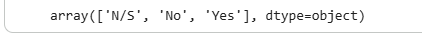

В заполнении категориальных данных в этот раз я использовала запосление констатной. Так как недостающие значения были в колонке "Research", то заполнение наиболее часто встречающимся значением было бы некорректно. А значение "N/S", которое было поставлено на замену пропуска, дает возможность запомнить место недостающей информации и затем уточнить данные у поступающего.